# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from scipy.io.wavfile import read
from scipy import signal
from IPython.display import Audio
import librosa
from librosa import feature, frames_to_time, autocorrelate, clicks, display
from collections import Counter

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [42]:
from scipy.io.wavfile import read

#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

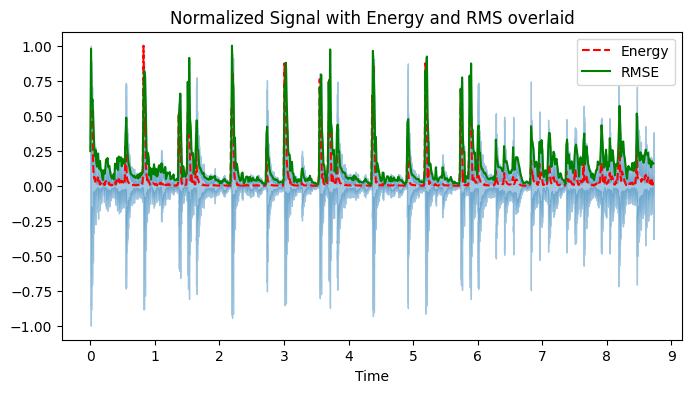

In [43]:
#80's Pop Drums

(fs, x) = read(r'C:\Users\kslap\OneDrive\Desktop\Kieran gt\Audiotech2\AudioTechII\audio\80spopDrums.wav')

#The Black Key's 

#(fs, x) = read(r'C:\Users\kslap\OneDrive\Desktop\Kieran gt\Audiotech2\AudioTechII\audio\TheBlackKeys_track4.wav')

#Prelude

#(fs, x) = read(r'C:\Users\kslap\OneDrive\Desktop\Kieran gt\Audiotech2\AudioTechII\audio\prelude_cmaj_10s.wav')


dur = x.size/fs
time = np.arange(0, dur, 1/fs)
#normalize amplitude
xnorm = x/np.abs(x.max())


hop_length = 512
frame_length = 512

energy = np.array([sum(abs(xnorm[i:i+frame_length]**2)) for i in range(0, len(xnorm), hop_length)])

rmse = librosa.feature.rms(y = xnorm, frame_length=frame_length, hop_length=hop_length, center=True)

frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)

librosa.display.waveshow(xnorm, sr=fs, alpha=0.4)
plt.plot(t, energy/energy.max(), 'r--', label='Energy')       
plt.plot(t, rmse[0]/rmse[0].max(), color='g', label='RMSE')  
plt.title('Normalized Signal with Energy and RMS overlaid')
plt.legend()


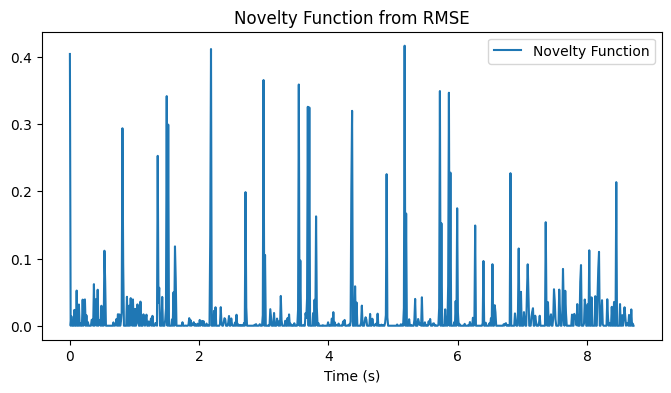

In [44]:
rmse_diff = np.diff(rmse[0])
novelty = np.concatenate((rmse_diff, np.array([0]))) 
novelty[novelty < 0] = 0
plt.plot(t, novelty, label='Novelty Function')
plt.xlabel('Time (s)')
plt.title('Novelty Function from RMSE')
plt.legend()
plt.show()

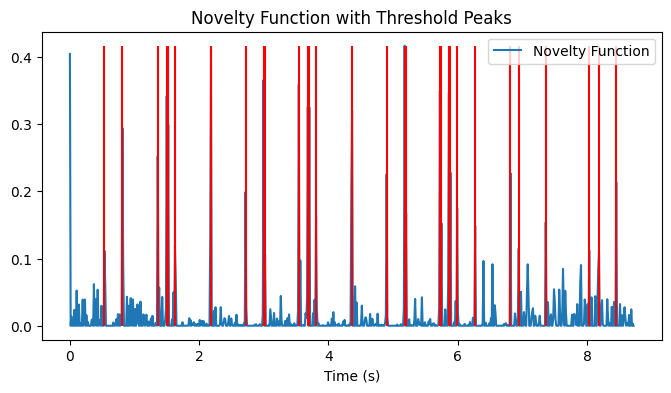

In [45]:
threshold = 0.1
peak_indices = []

for i in range(1, len(novelty)-1):
    if novelty[i] > threshold:
        if novelty[i] > novelty[i-1] and novelty[i] > novelty[i+1]:
            peak_indices.append(i)

peak_indices = np.array(peak_indices)
peak_times = t[peak_indices]

plt.plot(t, novelty, label='Novelty Function')
plt.vlines(peak_times, 0, np.max(novelty), colors='r')
plt.xlabel('Time (s)')
plt.title('Novelty Function with Threshold Peaks')
plt.legend()
plt.show()

## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

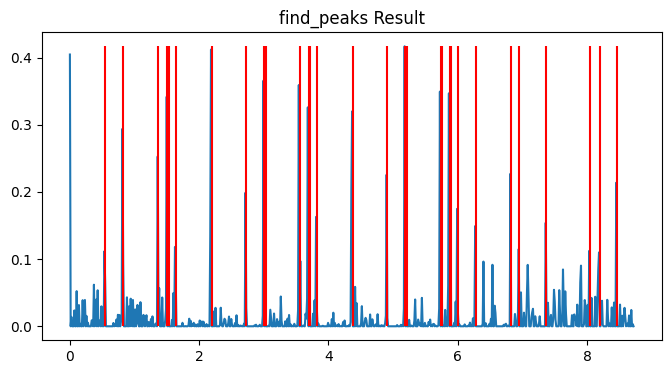

In [46]:
peaks, properties = signal.find_peaks(novelty, height=0.1)

peak_times = t[1:][peaks]

plt.plot(t, novelty)
plt.vlines(peak_times, 0, np.max(novelty), colors='r')
plt.title('find_peaks Result')
plt.show()

In [57]:
iois = np.diff(peak_times)

num_counts = Counter(iois)
top_n = num_counts.most_common(3)
tempa = 60 / .0232
tempb = 60 / .104
tempc = 60 / .522

tempList = [tempa, tempb, tempc]
final = []
for i in tempList:
    if i > 350 or i < 40:
        continue
    else:
        final.append(i)

print(final)


[114.94252873563218]


2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

Text(0.5, 1.0, 'Autocorrelation of Energy Differential')

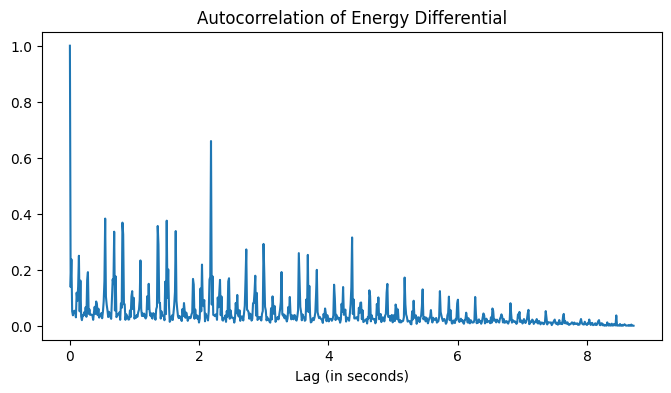

In [47]:
ac = librosa.autocorrelate(novelty)
ac = ac / ac.max()
lags = np.arange(len(ac))
plt.plot(lags * hop_length / fs, ac)
plt.xlabel("Lag (in seconds)")
plt.title("Autocorrelation of Energy Differential")

In [48]:
points = np.where(ac > 0.3) 
points = np.array(points)
t_inc = hop_length * points / fs
ts = t_inc[0][2:]
durs = ts[1:] - ts[:-1]
durs = np.round(durs, 3) 

num_counts = Counter(durs)
top_n = num_counts.most_common(3)

tempa = 60 / .267
tempb = 60 / .012
tempc = 60 / .534

tempList = [tempa, tempb, tempc]
final = []
for i in tempList:
    if i > 350 or i < 40:
        continue
    else:
        final.append(i)

print(final)



[224.7191011235955, 112.35955056179775]



Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?